## Analyzing Providers & Receivers


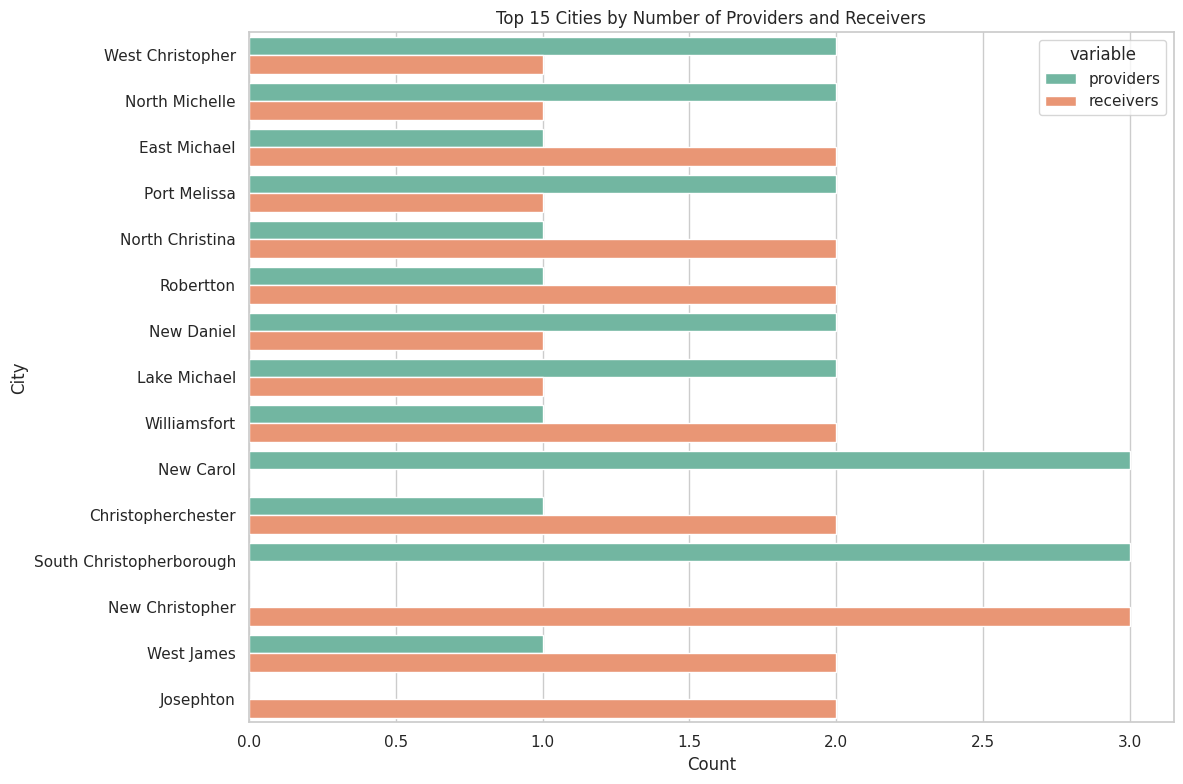

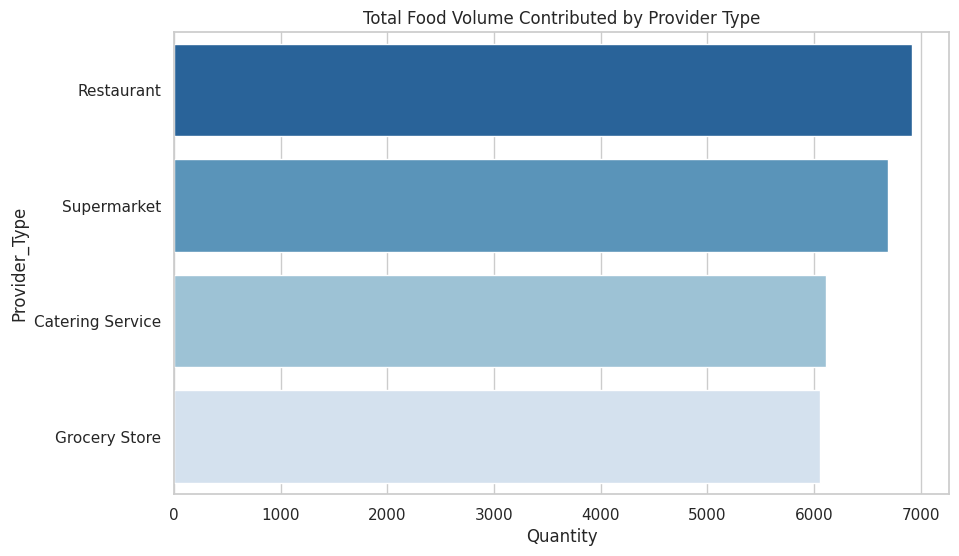

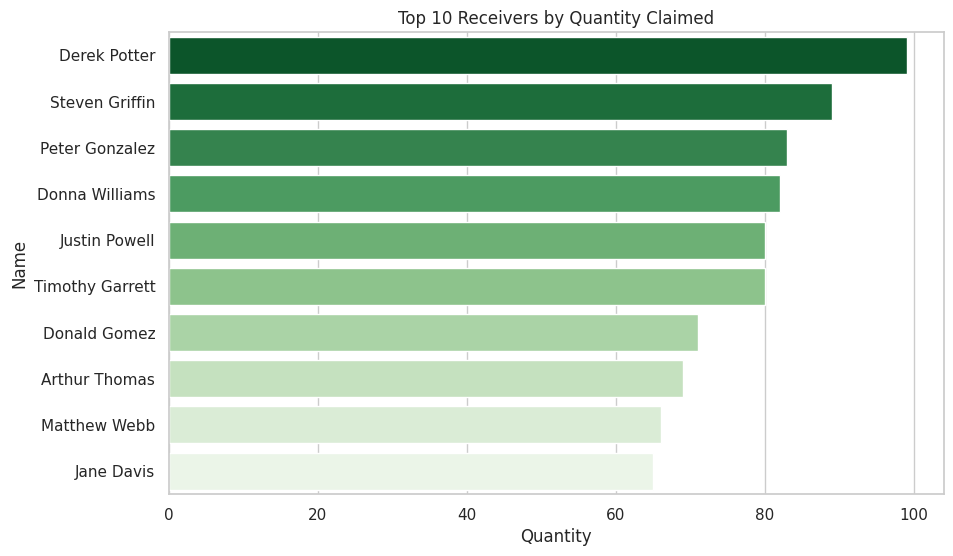


## Analyzing Food Listings & Availability
**Total Food Quantity Available:** 25794


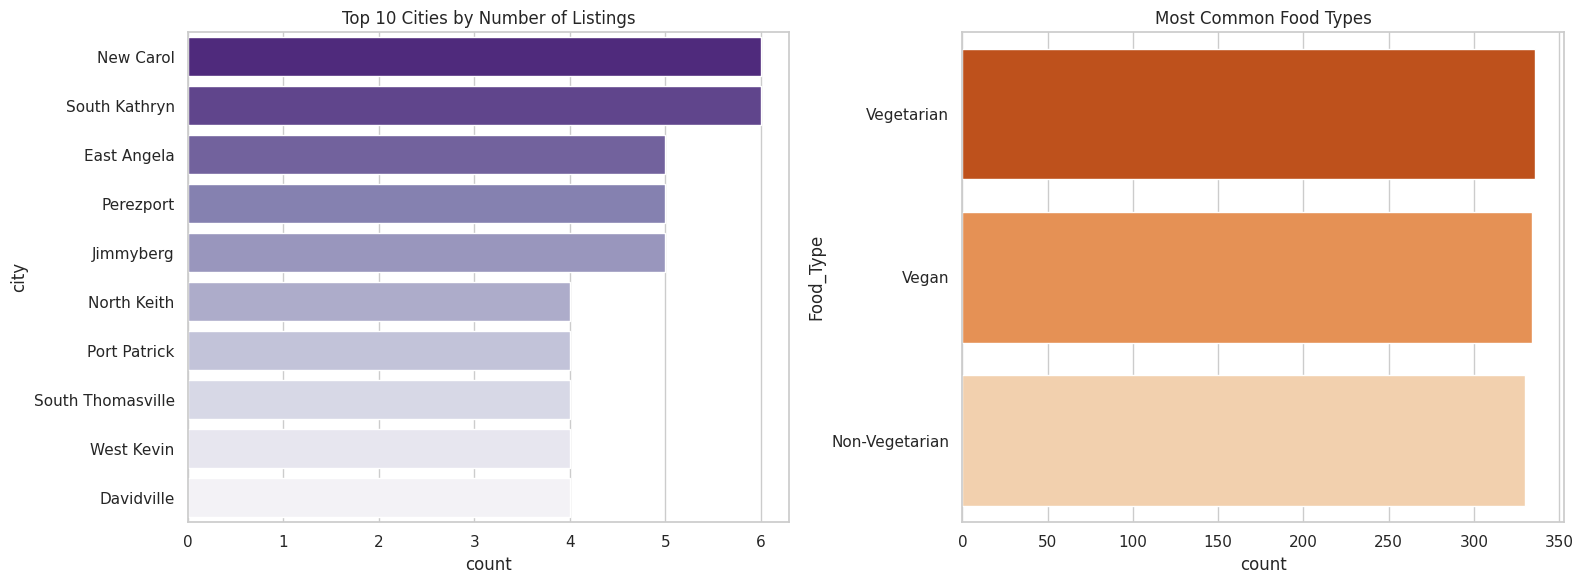


## Analyzing Claims & Distribution


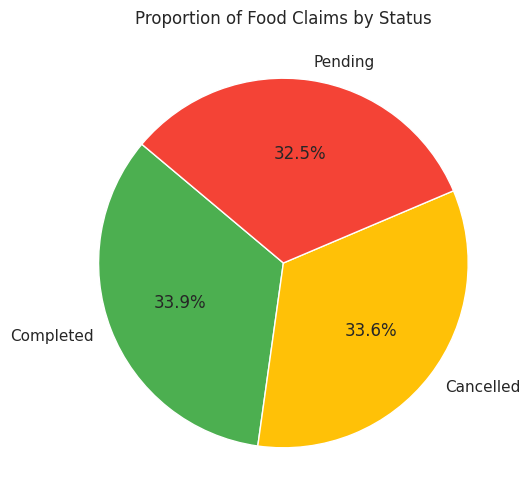


## Strategic Insights & Operational Trends
**Average Quantity Claimed Per Receiver:** 29.94


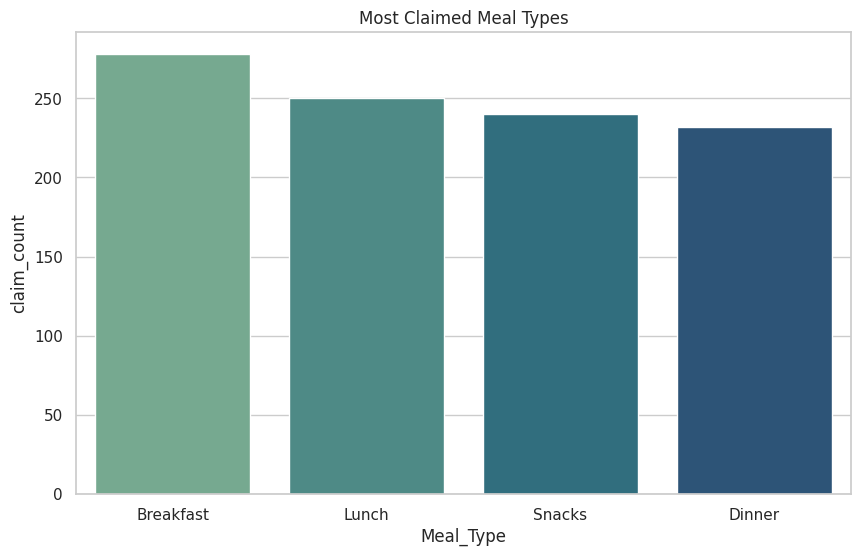


⚠️ **High Risk Items (Expiring Soonest & Unclaimed):**
Food_Name  Quantity Expiry_Date        Location              Name
     Rice        10  2025-03-16 West Sharonview Schmidt-Alexander
     Soup        40  2025-03-16     Maynardstad    Carlson-Mathis
  Chicken        17  2025-03-16   Katherinefurt         Olson Ltd
    Dairy        35  2025-03-16     Michaelport Aguilar-Frederick
  Chicken        29  2025-03-16     North Tracy   Mitchell-Watson


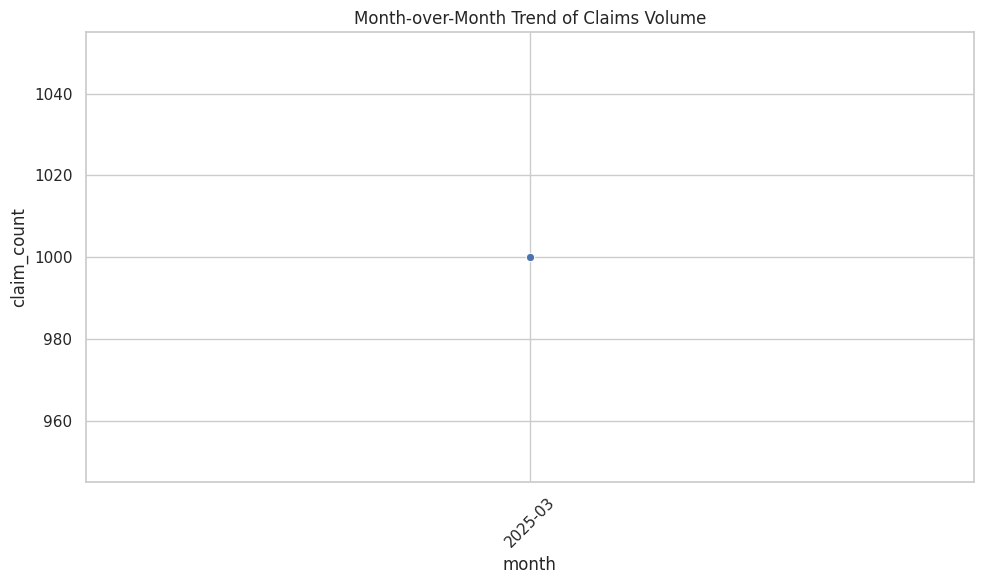

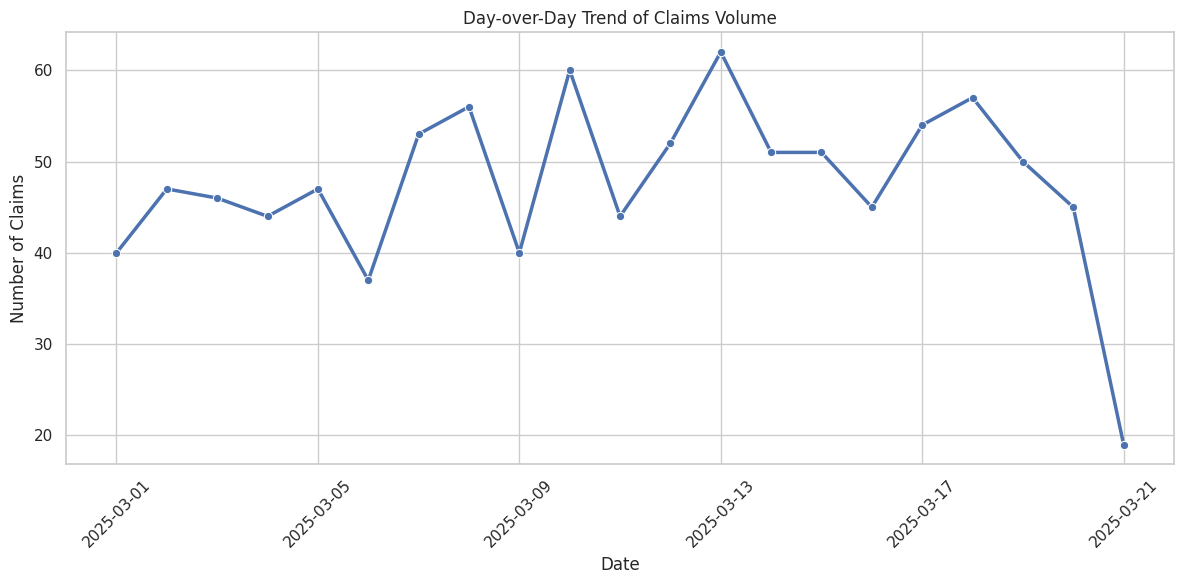

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- Pre-requisite: Set up professional plot styles ---
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# FILE
providers = pd.read_csv('/content/providers_data.csv')
receivers = pd.read_csv('/content/receivers_data.csv')
food_listings = pd.read_csv('/content/food_listings_data.csv')
claims = pd.read_csv('/content/claims_data.csv')


# ----------------------------------------------------------------------
# PART 1: FOOD PROVIDERS & RECEIVERS
# ----------------------------------------------------------------------
print("## Analyzing Providers & Receivers")

# Q1: How many food providers and receivers are there in each city? (Top 15 Cities)
prov_counts = (
    providers.groupby("City")["Provider_ID"].nunique().reset_index(name="providers")
)
rec_counts = (
    receivers.groupby("City")["Receiver_ID"].nunique().reset_index(name="receivers")
)
df_city_split = pd.merge(prov_counts, rec_counts, on="City", how="outer").fillna(0)

# Calculate total presence to find the top active cities
df_city_split["total"] = df_city_split["providers"] + df_city_split["receivers"]
df_top_cities = df_city_split.sort_values(by="total", ascending=False).head(15)

# Melt only the top 15 cities
df_melted = df_top_cities.melt(
    id_vars="City", value_vars=["providers", "receivers"]
)

# Plotting horizontally for readability
plt.figure(figsize=(12, 8))
sns.barplot(data=df_melted, y="City", x="value", hue="variable", palette="Set2")
plt.title("Top 15 Cities by Number of Providers and Receivers")
plt.xlabel("Count")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Q2: Which type of food provider contributes the most food?
df_p_type = (
    food_listings.groupby("Provider_Type")["Quantity"]
    .sum()
    .reset_index()
    .sort_values(by="Quantity", ascending=False)
)
plt.figure()
sns.barplot(data=df_p_type, x="Quantity", y="Provider_Type", hue="Provider_Type", palette="Blues_r", legend=False)
plt.title("Total Food Volume Contributed by Provider Type")
plt.show()

# Q3: Get contact information of food providers in a specific city
target_city = "New York"  # Example city filter
df_contacts = providers[providers["City"] == target_city][
    ["Name", "Type", "Address", "Contact"]
]

# Q4: Top 10 receivers who have claimed the most food (completed claims only)
completed_claims = claims[claims["Status"] == "Completed"]
m_rec = completed_claims.merge(receivers, on="Receiver_ID").merge(
    food_listings, on="Food_ID"
)
top_receivers = (
    m_rec.groupby("Name")["Quantity"]
    .sum()
    .reset_index()
    .sort_values(by="Quantity", ascending=False)
    .head(10)
)

plt.figure()
sns.barplot(data=top_receivers, x="Quantity", y="Name", hue="Name", palette="Greens_r", legend=False)
plt.title("Top 10 Receivers by Quantity Claimed")
plt.show()


# ----------------------------------------------------------------------
# PART 2: FOOD LISTINGS & AVAILABILITY
# ----------------------------------------------------------------------
print("\n## Analyzing Food Listings & Availability")

# Q5: Total quantity of food available from all providers
total_qty = food_listings["Quantity"].sum()
print(f"**Total Food Quantity Available:** {total_qty}")

# Q6 & Q7: Top Cities and Common Food Types Side-by-Side
# FIX: Explicitly naming the columns in reset_index to support all Pandas versions
top_cities = (
    food_listings["Location"]
    .value_counts()
    .reset_index(name="count")
    .rename(columns={"Location": "city"})  # Fixed column target
    .head(10)
)
food_types = food_listings["Food_Type"].value_counts().reset_index(name="count")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    ax=axes[0], data=top_cities, x="count", y="city", hue="city", palette="Purples_r", legend=False
)
axes[0].set_title("Top 10 Cities by Number of Listings")

sns.barplot(
    ax=axes[1], data=food_types, x="count", y="Food_Type", hue="Food_Type", palette="Oranges_r", legend=False
)
axes[1].set_title("Most Common Food Types")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# PART 3: CLAIMS & DISTRIBUTION
# ----------------------------------------------------------------------
print("\n## Analyzing Claims & Distribution")

# Q8: Food claims made for each food item (Top 15)
claims_per_item = (
    food_listings.merge(claims, on="Food_ID", how="left")
    .groupby(["Food_ID", "Food_Name"])
    .size()
    .reset_index(name="claim_count")
    .sort_values(by="claim_count", ascending=False)
    .head(15)
)

# Q9: Top providers by successful (completed) claims
# FIX: Explicit suffixes to avoid suffix confusion (_rec, _prov)
m_prov = (
    completed_claims.merge(receivers, on="Receiver_ID", suffixes=('', '_rec'))
    .merge(food_listings, on="Food_ID")
    .merge(providers, on="Provider_ID", suffixes=('', '_prov'))
)

top_providers = (
    m_prov.groupby("Name_prov")  # Explicitly targeting provider name
    .size()
    .reset_index(name="completed_claims")
    .sort_values(by="completed_claims", ascending=False)
    .head(10)
)

# Q10: Percentage of food claims completed vs pending vs cancelled
status_counts = claims["Status"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4CAF50", "#FFC107", "#F44336"],
)
plt.title("Proportion of Food Claims by Status")
plt.show()

# ----------------------------------------------------------------------
# PART 4: ANALYSIS & INSIGHTS
# ----------------------------------------------------------------------
print("\n## Strategic Insights & Operational Trends")

# Q11: Average quantity of food claimed per receiver (completed claims)
avg_qty_receiver = (
    m_rec.groupby("Receiver_ID")["Quantity"].sum().mean().round(2)
)
print(f"**Average Quantity Claimed Per Receiver:** {avg_qty_receiver}")

# Q12: Which meal type is claimed the most?
meal_trends = (
    claims.merge(food_listings, on="Food_ID")
    .groupby("Meal_Type")
    .size()
    .reset_index(name="claim_count")
    .sort_values(by="claim_count", ascending=False)
)
plt.figure()
sns.barplot(data=meal_trends, x="Meal_Type", y="claim_count", hue="Meal_Type", palette="crest", legend=False)
plt.title("Most Claimed Meal Types")
plt.show()

# Q13: Total quantity of food donated by each provider (Top 15)
provider_donations = (
    food_listings.merge(providers, on="Provider_ID")
    .groupby("Name")["Quantity"]
    .sum()
    .reset_index()
    .sort_values(by="Quantity", ascending=False)
    .head(15)
)

# Q14: Which unclaimed food items expire soonest? (Risk assessment)
completed_ids = claims[claims["Status"] == "Completed"]["Food_ID"]
unclaimed_food = food_listings[~food_listings["Food_ID"].isin(completed_ids)]
unclaimed_food = unclaimed_food.merge(providers, on="Provider_ID")

# Ensure expiry_date is handled as a datetime column for correct sorting
unclaimed_food["Expiry_Date"] = pd.to_datetime(unclaimed_food["Expiry_Date"])
high_risk_expiry = unclaimed_food.sort_values(by="Expiry_Date", ascending=True)[
    ["Food_Name", "Quantity", "Expiry_Date", "Location", "Name"]
].head(20)

print("\n⚠️ **High Risk Items (Expiring Soonest & Unclaimed):**")
print(high_risk_expiry.head(5).to_string(index=False))

# Q15: Monthly trend of claims (Volume changes Month-over-Month)
claims["Timestamp"] = pd.to_datetime(claims["Timestamp"])
claims["month"] = claims["Timestamp"].dt.to_period("M").astype(str)
monthly_trends = (
    claims.groupby("month").size().reset_index(name="claim_count")
)

plt.figure()
sns.lineplot(
    data=monthly_trends,
    x="month",
    y="claim_count",
    marker="o",
    linewidth=2.5,
    color="b",
)
plt.title("Month-over-Month Trend of Claims Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q15: Daily trend of claims (Volume changes day over day for the month)
claims["Timestamp"] = pd.to_datetime(claims["Timestamp"])

# Group by full date (YYYY-MM-DD) instead of just the month
claims["date"] = claims["Timestamp"].dt.date
daily_trends = claims.groupby("date").size().reset_index(name="claim_count")

# Sort chronologically
daily_trends = daily_trends.sort_values(by="date")

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_trends,
    x="date",
    y="claim_count",
    marker="o",
    linewidth=2.5,
    color="b",
)
plt.title("Day-over-Day Trend of Claims Volume")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()